<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

<h1 align=center><font size = 5>Hands-on Lab: Creating and Querying Database Objects from R using RSQLite with SQLite</h1> 


<br>


### Welcome!


In this hands-on lab, we will create and query database objects from an R notebook in Jupyter, and use ggplot2 to plot the data using R libraries.


<div class="alert alert-block alert-info" style="margin-top: 20px">
<h3>Tasks</h3>
<ol><ol><ol>
<li><a href="#ref4a">Pre-requisites & Dataset</a></li>
<li><a href="#ref4b">Load RSQLite</a></li>
<li><a href="#ref4c">Create a database connection</a></li>
<li><a href="#ref4f">Create the tables</a></li>
<li><a href="#ref4g">Load data into the database</a></li>
<li><a href="#ref4h">Fetch data from the database</a></li>
<li><a href="#ref4i">Plot the data (using ggplot2)</a></li>
</ol></ol></ol>
<br>
Estimated Time Needed: <strong>30 min</strong>
</div>


<a id="ref4a"></a>

### A. Pre-requisites & Dataset

**Pre-requisite**: In this lab we will use Jupyter Notebooks within SN Labs to access data using RSQLite.  Information about Jupyter notebooks, SN Labs.

**Dataset used in this lab**: For this lab we will utilize the Ontario public schools enrollment dataset. This data set is available under the Open **Government License – Ontario**.

For simplicity we have already split it into two separate files: [board.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork/labs/Lab%20-%20Creating%20and%20Querying%20Database%20Objects%20from%20R/board.csv) and [school.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork/labs/Lab%20-%20Creating%20and%20Querying%20Database%20Objects%20from%20R/school.csv).



<a id="ref4b"></a>

### B. Install and Load RSQLite

 Let’s load the RSQLite package by clicking on the following cell and executing it (Shift+Enter):


In [1]:
install.packages("https://cran.r-project.org/src/contrib/Archive/RSQLite/RSQLite_0.10.0.tar.gz", repos = NULL, type = "source", dependencies = TRUE)

Warning message in install.packages("https://cran.r-project.org/src/contrib/Archive/RSQLite/RSQLite_0.10.0.tar.gz", :
“installation of package ‘/tmp/Rtmpe3kfNF/downloaded_packages/RSQLite_0.10.0.tar.gz’ had non-zero exit status”


#### Restart Kernel

After installing the RSQLite package, it is necessary to restart R Kernel. Click **Kernel** > **Restart Kernel** from the main menu. This will register the newly installed packages. Now proceed to load the RSQLite package. 


In [1]:
library("RSQLite")

<a id="ref4c"></a>

### C. Create a database connection


In [2]:
conn <- dbConnect(RSQLite::SQLite(),"Querying_DatabaseDB.sqlite")

<h4>Let’s create the BOARD table in the database.</h4>


In [3]:
df1 <- dbExecute(conn, "CREATE TABLE BOARD (
                            B_ID CHAR(6) NOT NULL, 
                            B_NAME VARCHAR(75) NOT NULL, 
                            TYPE VARCHAR(50) NOT NULL, 
                            LANGUAGE VARCHAR(50), 
                            PRIMARY KEY (B_ID))")

<h4>Now let’s create the SCHOOL table with column details as:</br></br> B_ID CHAR, S_ID CHAR, S_NAME VARCHAR, LEVEL VARCHAR, ENROLLMENT INTEGER and B_ID, S_ID will be the primary key.</h4>


In [4]:
# write your solution here.
df2 <- dbExecute(conn, "CREATE TABLE SCHOOL (
                  B_ID CHAR(6) NOT NULL, 
                  S_ID CHAR(6) NOT NULL, 
                  S_NAME VARCHAR(100), 
                  LEVEL VARCHAR(70), 
                  ENROLLMENT INTEGER WITH DEFAULT 10,
                  PRIMARY KEY (B_ID, S_ID))")

<details>
<summary>Click here to view/hide solution</summary>
<p>

```
df2 <- dbExecute(conn, "CREATE TABLE SCHOOL (
                  B_ID CHAR(6) NOT NULL, 
                  S_ID CHAR(6) NOT NULL, 
                  S_NAME VARCHAR(100), 
                  LEVEL VARCHAR(70), 
                  ENROLLMENT INTEGER WITH DEFAULT 10,
                  PRIMARY KEY (B_ID, S_ID))") 
```

</details>


<a id="ref4g"></a>

### D. Load the data into the database


Fetch the tables present in the current database schema.


In [5]:
schooldf <- read.csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork/data/school.csv')
boarddf <- read.csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork/data/board.csv')

head(schooldf)
head(boarddf)

,B_ID,S_ID,S_NAME,LEVEL,ENROLLMENT
,<chr>,<int>,<chr>,<chr>,<int>
1,B28010,891240,Alexander Henry HS,Secondary,145
2,B28010,902344,Algoma Education Connection SS,Secondary,385
3,B28010,19186,Anna McCrea PS,Elementary,177
4,B28010,67679,Arthur Henderson PS,Elementary,104
5,B28010,28932,Aweres PS,Elementary,95
6,B28010,43362,Ben R McMullin PS,Elementary,241


,B_ID,B_NAME,TYPE,LANGUAGE
,<chr>,<chr>,<chr>,<chr>
1,B28010,Algoma DSB,Public,English
2,B67202,Algonquin and Lakeshore CDSB,Roman Catholic,English
3,B66010,Avon Maitland DSB,Public,English
4,B66001,Bluewater DSB,Public,English
5,B67164,Brant Haldimand Norfolk CDSB,Roman Catholic,English
6,B67008,Bruce-Grey CDSB,Roman Catholic,English


In [6]:
dbWriteTable(conn, "SCHOOL", schooldf, overwrite=TRUE, header = TRUE)

In [7]:
# Use dbWriteTable function to write the csv into created table name BOARD.
dbWriteTable(conn, "BOARD", boarddf, overwrite=TRUE, header = TRUE)

<details>
<summary>Click here to view/hide solution</summary>
<p>

```
dbWriteTable(conn, "BOARD", boarddf, overwrite=TRUE, header = TRUE)
```

</details>


### Check list of tables in the present database


In [8]:
dbListTables(conn)

[1] "BOARD"  "SCHOOL"

### Print details for the tables BOARD and SCHOOL


In [9]:
tables1 = dbListTables(conn)
for (table in tables1){  
        cat ("\nColumn info for table", table, ":\n")
        col.detail <- dbColumnInfo(dbSendQuery(conn,paste( "select * from",table)))
        print(col.detail)
}


Column info for table BOARD :
      name      type
1     B_ID character
2   B_NAME character
3     TYPE character
4 LANGUAGE character

Column info for table SCHOOL :


Warning message:
“Closing open result set, pending rows”


        name      type
1       B_ID character
2       S_ID   integer
3     S_NAME character
4      LEVEL character
5 ENROLLMENT   integer


Display initial data from the BOARD dataframe.


In [10]:
dbGetQuery(conn, 'SELECT * FROM BOARD limit 5')

Warning message:
“Closing open result set, pending rows”


B_ID,B_NAME,TYPE,LANGUAGE
<chr>,<chr>,<chr>,<chr>
B28010,Algoma DSB,Public,English
B67202,Algonquin and Lakeshore CDSB,Roman Catholic,English
B66010,Avon Maitland DSB,Public,English
B66001,Bluewater DSB,Public,English
B67164,Brant Haldimand Norfolk CDSB,Roman Catholic,English


Display some records from the beginning of the SCHOOL dataframe.


In [11]:
# write your solution here.
dbGetQuery(conn, 'SELECT * FROM SCHOOL limit 5')

B_ID,S_ID,S_NAME,LEVEL,ENROLLMENT
<chr>,<int>,<chr>,<chr>,<int>
B28010,891240,Alexander Henry HS,Secondary,145
B28010,902344,Algoma Education Connection SS,Secondary,385
B28010,19186,Anna McCrea PS,Elementary,177
B28010,67679,Arthur Henderson PS,Elementary,104
B28010,28932,Aweres PS,Elementary,95


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
dbGetQuery(conn, 'SELECT * FROM  SCHOOL limit 5')
```

</details>


<a id="ref4h"></a>

### H. Fetch data from the database


Fetch the data from the database table BOARD and display some rows from the end of the data.


In [12]:
boarddb <- dbGetQuery(conn, 'SELECT * FROM BOARD limit 5')
tail(boarddb)

,B_ID,B_NAME,TYPE,LANGUAGE
,<chr>,<chr>,<chr>,<chr>
1,B28010,Algoma DSB,Public,English
2,B67202,Algonquin and Lakeshore CDSB,Roman Catholic,English
3,B66010,Avon Maitland DSB,Public,English
4,B66001,Bluewater DSB,Public,English
5,B67164,Brant Haldimand Norfolk CDSB,Roman Catholic,English


Fetch the data from the database table SCHOOL and display some rows from the end of the data.


In [13]:
# write your solution here.
schooldb <- dbGetQuery(conn, 'SELECT * FROM SCHOOL limit 5')
tail(schooldb)

,B_ID,S_ID,S_NAME,LEVEL,ENROLLMENT
,<chr>,<int>,<chr>,<chr>,<int>
1,B28010,891240,Alexander Henry HS,Secondary,145
2,B28010,902344,Algoma Education Connection SS,Secondary,385
3,B28010,19186,Anna McCrea PS,Elementary,177
4,B28010,67679,Arthur Henderson PS,Elementary,104
5,B28010,28932,Aweres PS,Elementary,95


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
schooldb <- dbGetQuery(conn, 'SELECT * FROM  SCHOOL limit 5')
tail(schooldb)
```

</details>


<a id="ref4i"></a>

### I. Plot the data (using ggplot2)


In [14]:
library(ggplot2);

<h4>Get the elementary school data from the database from both tables in descending sequence.</h4>


In [15]:
elequery <- paste("select ENROLLMENT 
from SCHOOL s, BOARD b 
where b.B_NAME = 'Toronto DSB' and b.B_ID=s.B_ID 
and s.LEVEL = 'Elementary' 
order by ENROLLMENT desc")

<h4>Create the elementary school dataframe.</h4>


In [16]:
eledf <- dbGetQuery(conn, elequery)
dim(eledf)

[1] 476   1

<h4>Create a density plot of elementary school enrollments.</h4>


Warning message:
“`qplot()` was deprecated in ggplot2 3.4.0.”


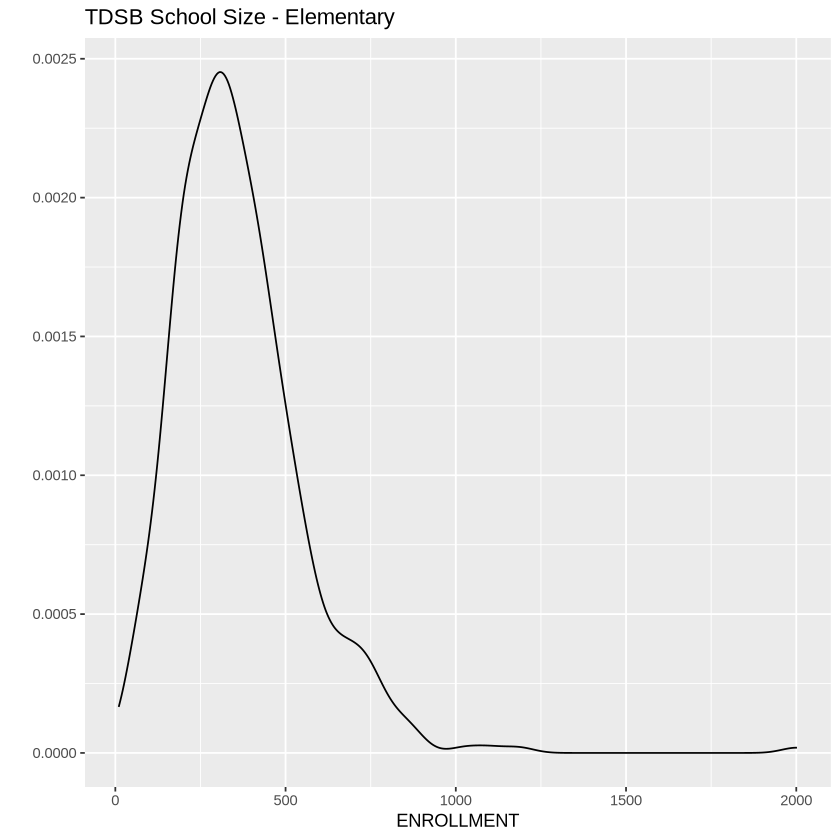

In [17]:
qplot(ENROLLMENT, data=eledf, geom="density",  main="TDSB School Size - Elementary")

<h4>Create the secondary school enrollments query in descending sequence.</h4>


In [18]:
# write your solution here.
secquery <- paste("select s.ENROLLMENT 
from SCHOOL s, BOARD b 
where b.B_NAME = 'Toronto DSB' and b.B_ID=s.B_ID
and s.LEVEL = 'Secondary' 
order by ENROLLMENT desc")

<details>
<summary>Click here to view/hide hint</summary>
<p>

```
# Fill in the ...
sec... <- paste("... s.enrollment as ... 
from ... s, board b 
where b.b_... = 'Toronto ...' and b.b_id=s.... 
and s.... = 'Secondary' 
order by ... desc")
```

</details>


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
secquery <- paste("select s.ENROLLMENT 
from SCHOOL s, BOARD b 
where b.B_NAME = 'Toronto DSB' and b.B_ID=s.B_ID
and s.LEVEL = 'Secondary' 
order by ENROLLMENT desc")
```

</details>


<h4>Create the dataframe using the data in the database.</h4>


In [20]:
# write your solution here.
secdf <- dbGetQuery(conn, secquery)
str(secdf)
head(secdf)

'data.frame':	121 obs. of  1 variable:
 $ ENROLLMENT: int  2209 1993 1838 1800 1721 1519 1507 1504 1496 1456 ...


,ENROLLMENT
,<int>
1,2209
2,1993
3,1838
4,1800
5,1721
6,1519


<details>
<summary>Click here to view/hide hint</summary>
<p>

```
# Fill in the ...
secdf <- dbGet...(conn, sec...)
```

</details>


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
secdf <- dbGetQuery(conn, secquery)
```

</details>


<h4>Create a density plot of secondary school enrollments.</h4>


Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_density()`).”


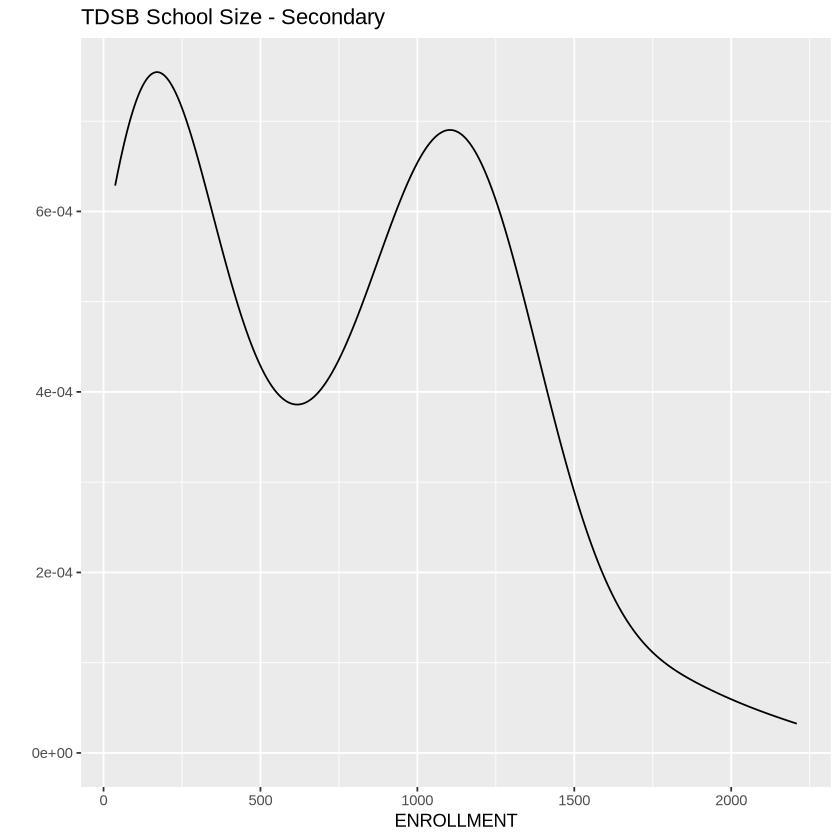

In [21]:
# write your solution here.
qplot(ENROLLMENT, data=secdf, geom="density", main="TDSB School Size - Secondary")

<details>
<summary>Click here to view/hide hint</summary>
<p>

```
# Fill in the ...
q...(ENROLLMENT, ...=secdf, ...="density", ...="TDSB School Size - ...")
```

</details>


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
qplot(ENROLLMENT, data=secdf, geom="density", main="TDSB School Size - Secondary")
```

</details>


<h4>Query the BOARD database for enrollments.</h4>


In [22]:
# write your solution here.
denquery <- paste("select b.B_NAME, s.S_NAME, LEVEL , ENROLLMENT 
 from BOARD b, SCHOOL s where b.B_ID = s.B_ID and b.B_NAME = 'Toronto DSB'")

<details>
<summary>Click here to view/hide hint</summary>
<p>

```
# Fill in the ...
den... <- paste("select b.b_..., s.s_..., level as ..., ... 
 from board b, ... s where b.... = s.b_id and b.b_... = 'Toronto DSB'")
```

</details>


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
denquery <- paste("select b.B_NAME, s.S_NAME, LEVEL , ENROLLMENT 
 from BOARD b, SCHOOL s where b.B_ID = s.B_ID and b.B_NAME = 'Toronto DSB'")
```

</details>


<h4>Query the database.</h4>


In [23]:
# write your solution here.
dendf <- dbGetQuery(conn, denquery)
dim(dendf)

[1] 597   4

<details>
<summary>Click here to view/hide hint</summary>
<p>

```
# Fill in the ...
d...f <- dbGet...(conn, den...)
```

</details>


<details>
<summary>Click here to view/hide solution</summary>
<p>

```
dendf <- dbGetQuery(conn, denquery)
```

</details>


<h4>Create a box plot of enrollments in elementary and secondary schools in Toronto.</h4>


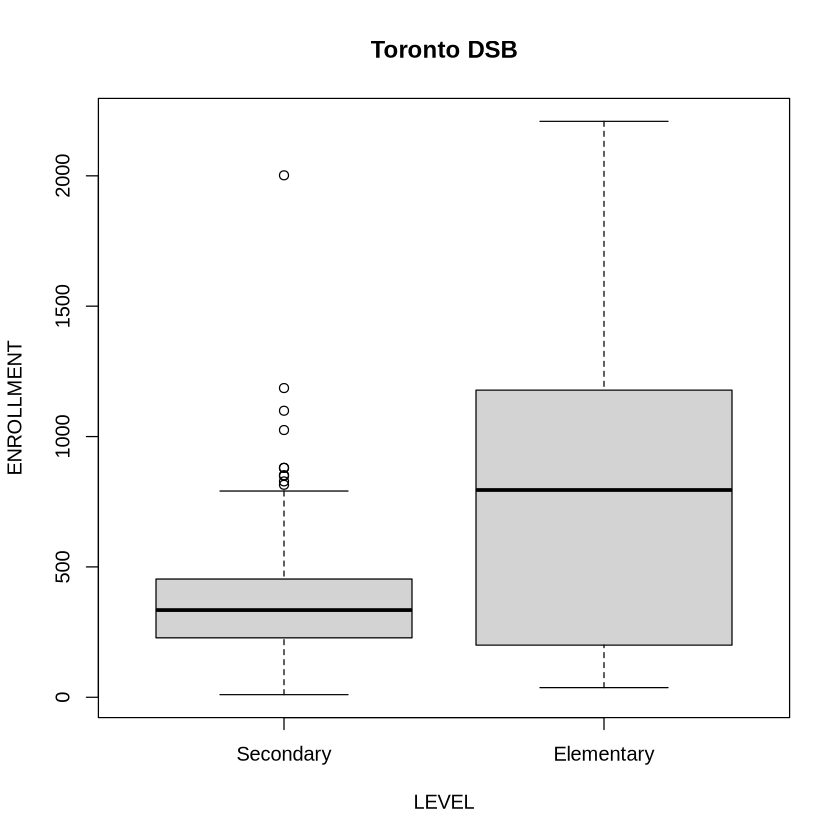

In [24]:
# write your solution here
dendf$LEVEL <- as.factor(dendf$LEVEL)
boxplot(ENROLLMENT ~ LEVEL, dendf, names =c("Secondary","Elementary"), main="Toronto DSB")

<details>
<summary>Click here to view/hide solution</summary>
<p>

```
dendf$LEVEL <- as.factor(dendf$LEVEL)
boxplot(ENROLLMENT ~ LEVEL, dendf, names =c("Secondary","Elementary"), main="Toronto DSB")
```

</details>


<a id="ref4o"></a>

### Summary


In this lab you created and queried database objects from an R notebook in Jupyter, and you used ggplot2 to plot the data using R libraries.


<hr>


#### Thank you for completing this module on creating and querying database objects from R.


<hr>

## Authors

-   [Rav Ahuja](https://ca.linkedin.com/in/rav-ahuja-8aa4562a?cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)
-   [Agatha Colangelo](https://www.linkedin.com/in/agathacolangelo?cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)
-   [Sandip Saha Joy](https://www.linkedin.com/in/sandipsahajoy?cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ&cm_mmc=Email_Newsletter-_-Developer_Ed%2BTech-_-WW_WW-_-SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-RP0103EN-SkillsNetwork-23619267&cm_mmca1=000026UJ&cm_mmca2=10006555&cm_mmca3=M12345678&cvosrc=email.Newsletter.M12345678&cvo_campaign=000026UJ)

## Contributor(s)

-   [D.M.NAIDU](https://www.linkedin.com/in/mrutyunjaya-naidu-duvvana/)


<h2 align=center><font size = 5>Copyright &copy; IBM Corporation 2024. All rights reserved.</h2>


```{toggle} ## Changelog
```

```{toggle} | Date (YYYY-MM-DD) | Version | Changed By                   | Change Description    |
```
```{toggle} | -----------------| ------- | ---------------------------- | ---------------------------------- |
```
```{toggle} | 2022-03-03       |  2.0    |  D.M. Naidu                  |  Converted intial version to RSQLite|
```
```{toggle} | 2021-01-22        | 2.0     | Sandip Saha Joy              | Created revised version of the lab |
```
```{toggle} | 2017              | 1.0     | Rav Ahuja & Agatha Colangelo | Created initial version of the lab |
```

